# 5. Historical special cases and DFT–experiment comparison

This notebook preserves the alternative special-reactant and experimental analyses from the tail of the source notebook. Each section has separate inputs; it is not one continuous calculation.

Saved outputs were cleared in this split. The archived source notebook retains the historical outputs and execution counts. Set the job paths before running any calculation.


In [2]:
from pathlib import Path
import os
import sys

# Find the repository from either the repository root or a notebook subdirectory.
REPO_ROOT = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "Code").is_dir() and (parent / "Data").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook from within the CycloAddGenerator repository")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
from Code import main, model_train

target_dir = r"G:\work\Secondary_Selection\pre_diene_reaction"


## Special reactant repair case (source cells 69–76)

Set `target_dir` to the specific historical job before running this section. These cells use the files of that job; they do not feed part 4 automatically.


In [ ]:
target_dir = r"G:\work\Secondary_Selection\pre_diene_reaction"

In [ ]:
main.ts_Z_E_check(target_dir, ts_name='ts', move_file='wrong_ZEH', ignore_H=False)

In [ ]:
main.check_product_stereo(target_dir)

In [ ]:
main.ts_up_down_check(target_dir, ts_name='ts', dust_bin="up_down_fail_ts")

In [ ]:
main.rotated_reactant(target_dir)

In [ ]:
main.error_improve(target_dir, 'special_reactant')

In [ ]:
main.ts_SPE_DFT_calc(target_dir, "special_reactant", "special_reactant_eng")

In [ ]:
main.error_improve(target_dir, 'special_reactant_eng')

## DFT–experiment comparison (source cells 79–85)

`DFT_EXP.csv` now lives in `Data/DFT_Result/`.


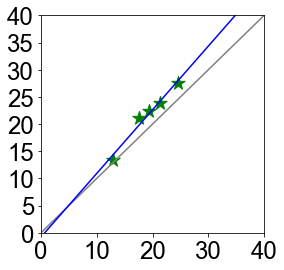

In [5]:
from Code import model_train
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
csv = pd.read_csv(REPO_ROOT / "Data" / "DFT_Result" / "DFT_EXP.csv")
calc_value = csv["deltaGa(Solvent2)"][2:].to_numpy() - 1.89
exp_value = csv["DFT_EXP"][2:].to_numpy()
min_ = 0
max_ = 40
x = exp_value
y = calc_value

r2 = model_train.r2_score(x, y)

# Draw the scatter plot.
plt.figure(figsize=(4, 4))
plt.xlim(min_, max_)
plt.ylim(min_, max_)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
# plt.xlabel("Real", fontsize=18)
# plt.ylabel("Prediction", fontsize=18)
# if title != None:
#     plt.title("%s\nR2:%.3f, MAE:%.3f, MSE:%.3f" % (title, r2, mae, mse), fontsize=24)
#     plt.title("%s"%title,fontsize=24)
z = np.linspace(min_, max_, 10000)
plt.plot(z, z, c='gray')


# Add regression metrics below the plot.
model = LinearRegression()
model.fit(exp_value.reshape(-1, 1), calc_value)
plt.plot([min_, max_], model.predict([[min_], [max_]]), c='blue')
plt.scatter(x, y, marker="*", c="g", s=200)

# Display the plot.
plt.savefig("test.svg", format="svg")
plt.show()

In [4]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt

In [5]:
model.predict(exp_value.reshape(-1, 1))

array([23.79284989, 26.12358023, 21.59095389, 29.9534738 , 16.15648717])

In [6]:
model.score(exp_value.reshape(-1, 1), calc_value)

0.9683171665105837

In [7]:
model.coef_, model.intercept_, model.rank_

(array([1.17122128]), 1.1062937792411738, 1)